In [16]:
# Instalamos funcionalidades 
%pip install folium mapclassify
%pip install scikit-learn geopandas pandas numpy pyogrio
%pip install seaborn matplotlib statsmodels
%pip install libpysal spreg


   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   --------------------------------------- 882.2/882.2 kB 28.9 MB/s eta 0:00:00

   ------------- -------------------------- 1/3 [mapclassify]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



In [5]:
# Lectura de Librerías 
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# ------------------------------------------------------------
# 1. CARGA DE DATOS DE BOSTON
# ------------------------------------------------------------

url = "https://github.com/Nowosad/spData/raw/master/inst/shapes/boston_tracts.gpkg"
gdf = gpd.read_file(url)

print(gdf.head())
print(gdf.columns)

  poltract                     TOWN  TOWNNO  TRACT      LON      LAT  MEDV  \
0     0001  Boston Allston-Brighton    74.0    1.0 -71.0830  42.2172  17.8   
1     0002  Boston Allston-Brighton    74.0    2.0 -71.0950  42.2120  21.7   
2     0003  Boston Allston-Brighton    74.0    3.0 -71.1007  42.2100  22.7   
3     0004  Boston Allston-Brighton    74.0    4.0 -71.0930  42.2070  22.6   
4     0005  Boston Allston-Brighton    74.0    5.0 -71.0905  42.2033  25.0   

   CMEDV     CRIM   ZN  ...  C20_25 C25_35  C35_50  co50k   median   BB  \
0   17.8  8.98296  0.0  ...      29     16       1      1  17800.0  0.8   
1   21.7  3.84970  0.0  ...     139     93       9      5  21700.0  1.4   
2   22.7  5.20177  0.0  ...     127    102      24      0  22700.0  0.3   
3   22.6  4.26131  0.0  ...      67     63      12      3  22600.0  0.8   
4   25.0  4.54192  0.0  ...       9     12       9      1  25000.0  1.8   

   censored  NOX_ID   POP                                           geometry  
0

In [7]:
# ------------------------------------------------------------
# 2. CREACIÓN DE VARIABLE OBJETIVO Y TRANSFORMACIONES
# ------------------------------------------------------------

gdf["price"] = pd.to_numeric(gdf["CMEDV"], errors="coerce")
gdf["log_price"] = np.log(gdf["price"])

gdf["CRIM"] = pd.to_numeric(gdf["CRIM"], errors="coerce")
gdf["DIS"] = pd.to_numeric(gdf["DIS"], errors="coerce")

gdf["log_crime"] = np.log1p(gdf["CRIM"])
gdf["log_dis"] = np.log1p(gdf["DIS"])

covariables_list = [
    "log_crime",
    "RM",
    "LSTAT",
    "NOX",
    "log_dis",
    "PTRATIO",
    "TAX",
    "CHAS"
]

target_col = "log_price"

# Asegurar que todas las variables sean numéricas
for col in covariables_list + [target_col]:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

# Eliminar valores no válidos
gdf = gdf.replace([np.inf, -np.inf], np.nan)
gdf = gdf.dropna(subset=covariables_list + [target_col])

gdf = gdf.reset_index(drop=True)

print(gdf[covariables_list + [target_col]].dtypes)
print(gdf.shape)

log_crime    float64
RM           float64
LSTAT        float64
NOX          float64
log_dis      float64
PTRATIO      float64
TAX          float64
CHAS           int64
log_price    float64
dtype: object
(506, 41)


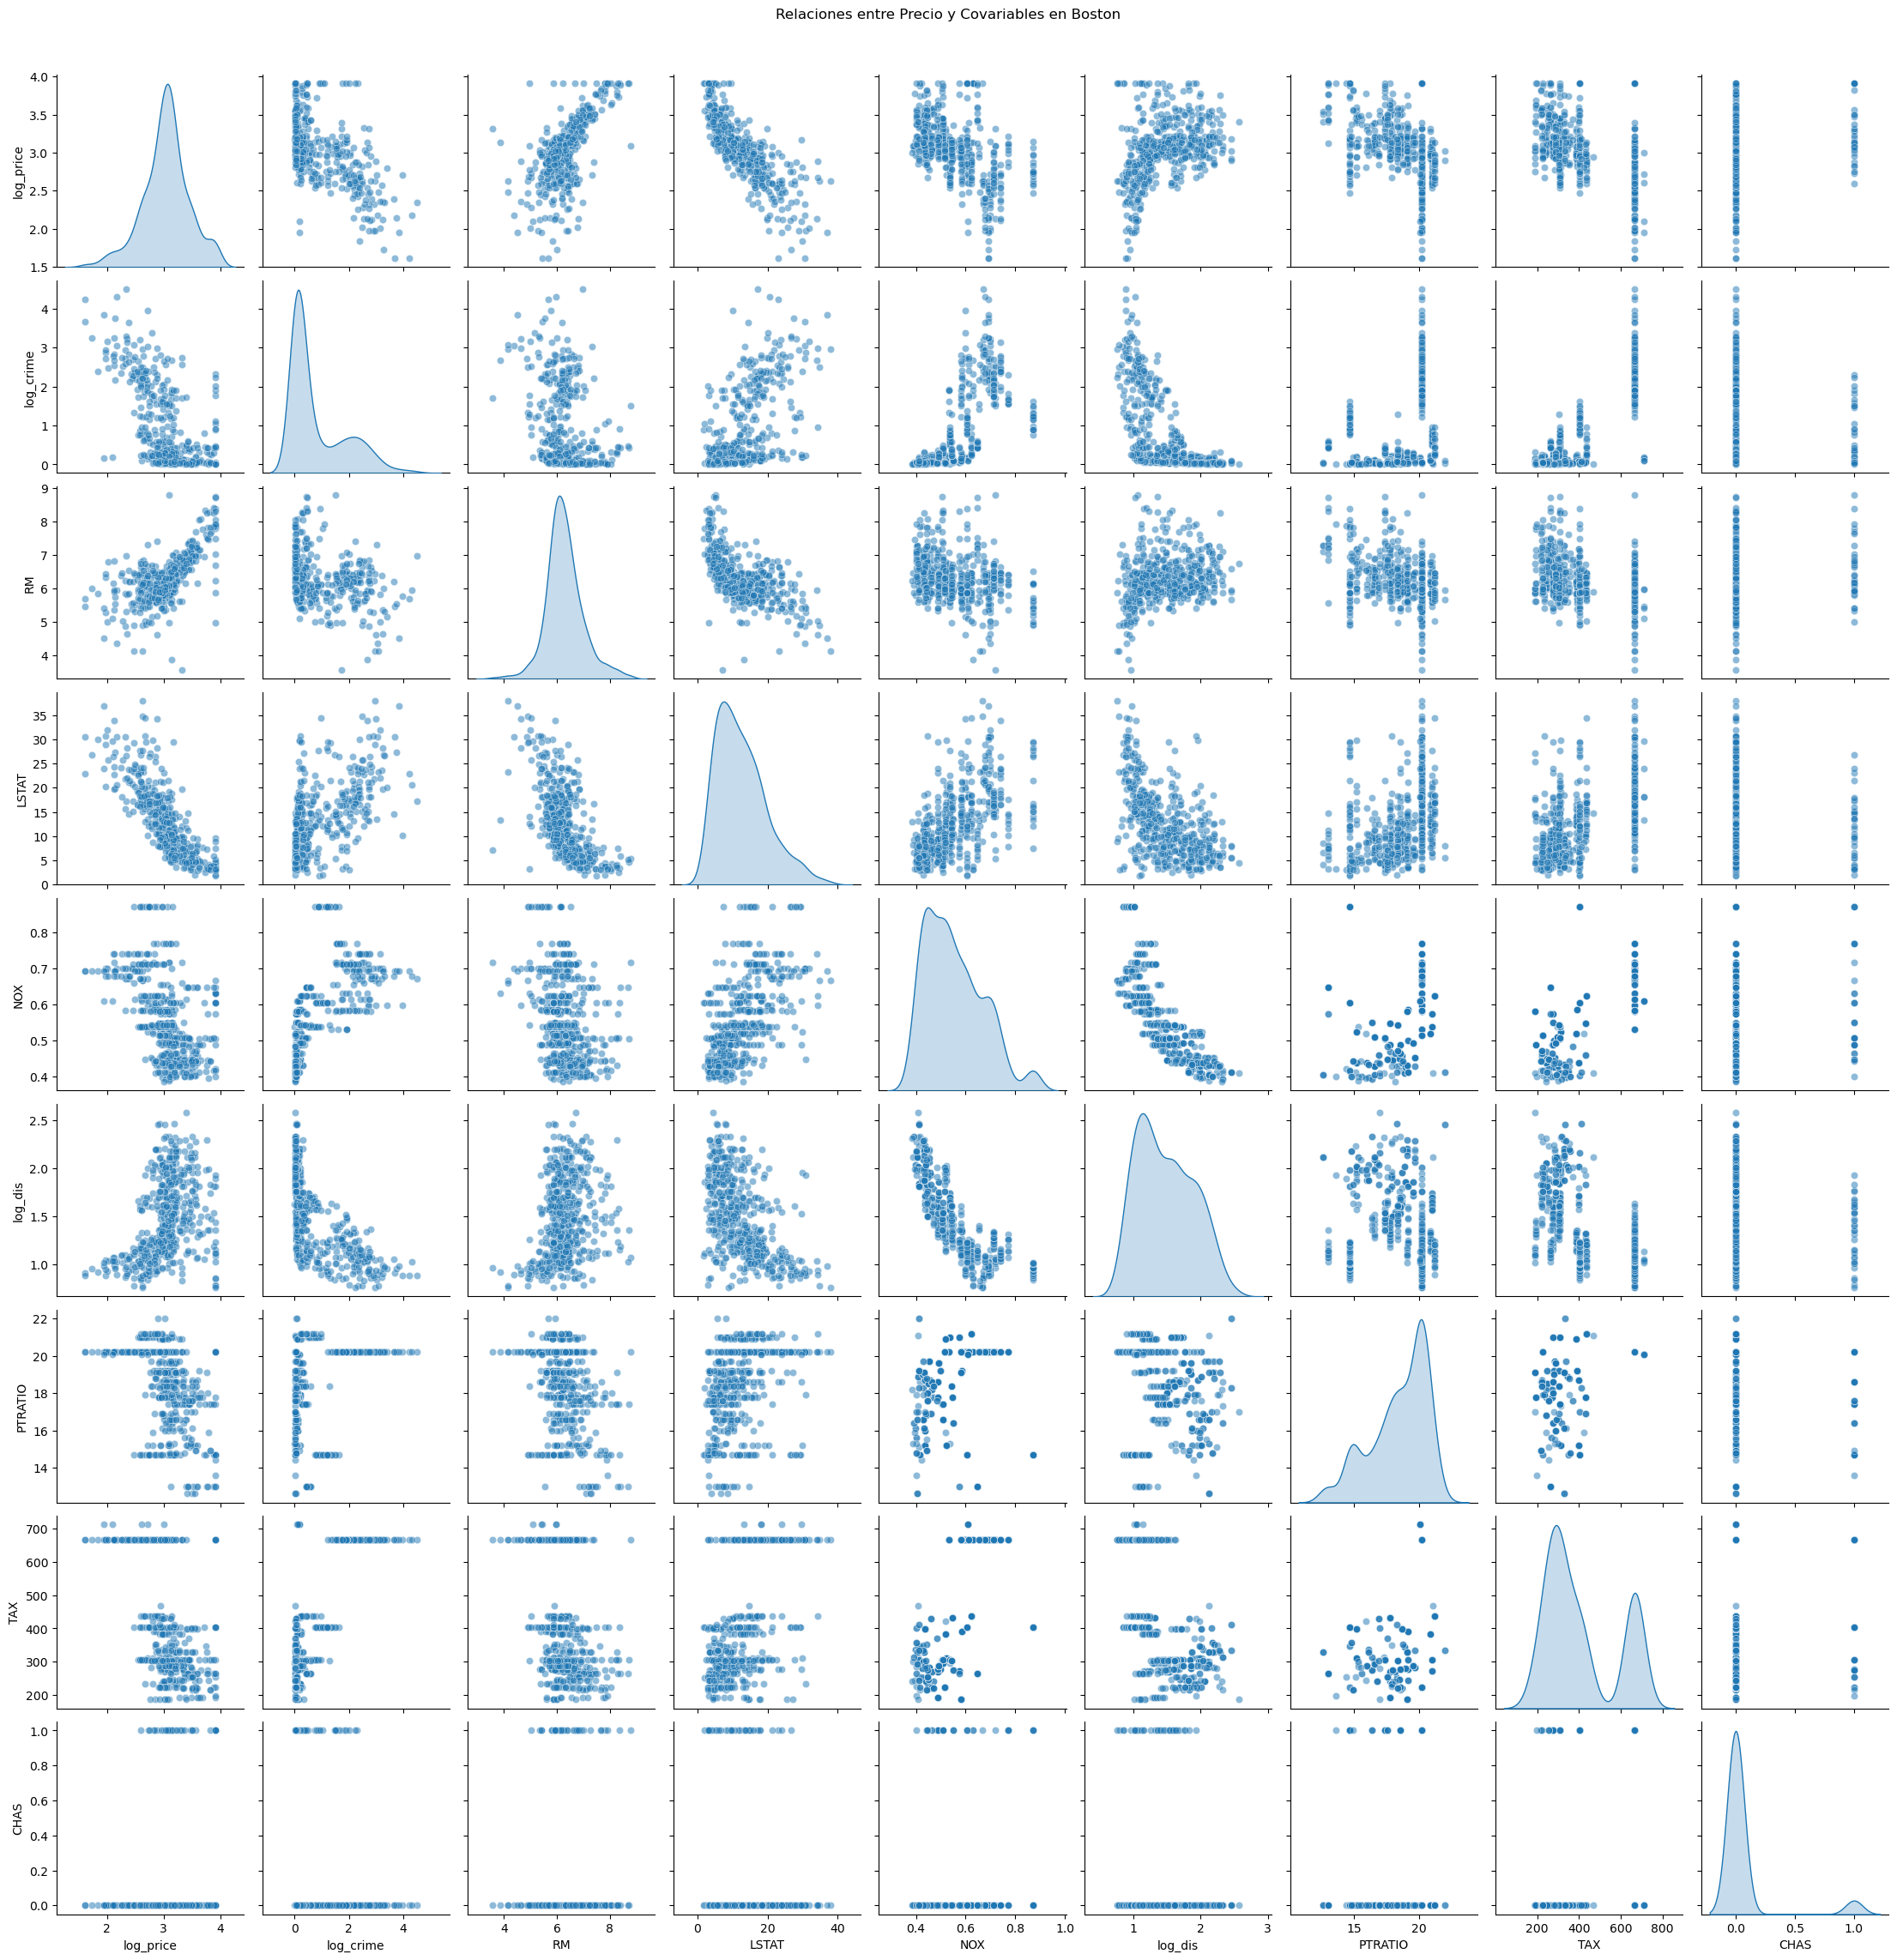

In [8]:
# ------------------------------------------------------------
# 3. ANÁLISIS EXPLORATORIO
# ------------------------------------------------------------

cols_to_plot = [target_col] + covariables_list

sns.pairplot(gdf[cols_to_plot], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Relaciones entre Precio y Covariables en Boston", y=1.02)
plt.show()

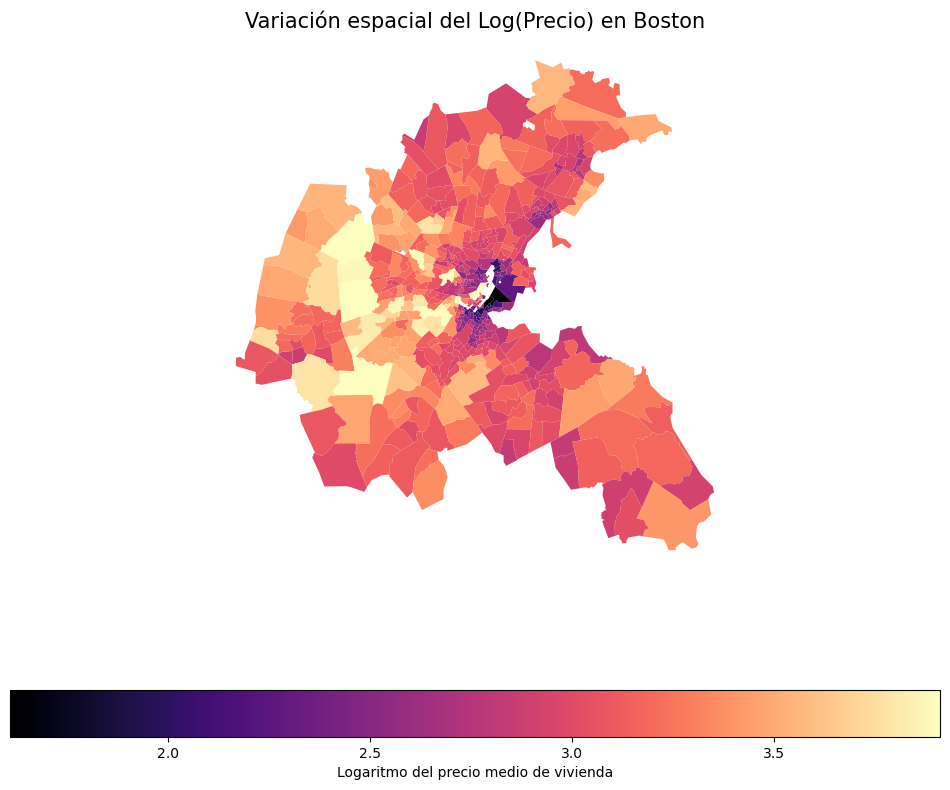

In [9]:
# ------------------------------------------------------------
# 4. MAPA DEL LOG-PRECIO
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf.plot(
    column="log_price",
    cmap="magma",
    legend=True,
    legend_kwds={
        "label": "Logaritmo del precio medio de vivienda",
        "orientation": "horizontal"
    },
    ax=ax
)

ax.set_title("Variación espacial del Log(Precio) en Boston", fontsize=15)
ax.set_axis_off()

plt.show()

In [10]:
# ------------------------------------------------------------
# 5. MAPA INTERACTIVO
# ------------------------------------------------------------

mapa_boston = gdf.explore(
    column="log_price",
    cmap="magma",
    tooltip=["CMEDV", "log_price"],
    popup=True,
    legend=True,
    tiles="CartoDB positron"
)

mapa_boston

In [11]:
# ------------------------------------------------------------
# 6. CONSTRUCCIÓN DE BLOQUES ESPACIALES MEDIANTE AHC
# ------------------------------------------------------------

centroids = gdf.geometry.centroid
coords = np.column_stack((centroids.x, centroids.y))

model_ahc = AgglomerativeClustering(
    n_clusters=5,
    linkage="complete"
)

gdf["block_id"] = model_ahc.fit_predict(coords)

print(f"Se han creado {gdf['block_id'].nunique()} bloques espaciales.")
print(gdf["block_id"].value_counts())

Se han creado 5 bloques espaciales.
block_id
1    321
2     62
3     53
0     46
4     24
Name: count, dtype: int64


C:\Users\charl\AppData\Local\Temp\ipykernel_90840\1252641113.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


In [12]:
df_blocks_aggregated = (
    gdf
    .groupby("block_id")
    .agg(diccionario_agregacion)
    .reset_index()
)

NameError: name 'diccionario_agregacion' is not defined

In [13]:
# ------------------------------------------------------------
# 7. ALGORITMO SPATIAL+ / HBGF
# ------------------------------------------------------------

def algorithm_2_hbgf(df_blocks, k_folds=5):
    
    n_blocks = len(df_blocks)
    
    if n_blocks < k_folds:
        raise ValueError(
            f"No hay suficientes bloques para crear {k_folds} folds. "
            f"Solo hay {n_blocks} bloques."
        )
    
    coords = df_blocks[["centroid_x", "centroid_y"]].values
    target = df_blocks[["log_price"]].values
    
    exclude = ["block_id", "centroid_x", "centroid_y", "log_price"]
    covariate_cols = [col for col in df_blocks.columns if col not in exclude]
    covariates = df_blocks[covariate_cols].values

    km_l = KMeans(
        n_clusters=k_folds,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    clusters_L = km_l.fit_predict(coords)
    
    km_c = KMeans(
        n_clusters=k_folds,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    clusters_C = km_c.fit_predict(covariates)
        
    km_t = KMeans(
        n_clusters=k_folds,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    clusters_T = km_t.fit_predict(target)

    H = np.zeros((n_blocks, k_folds * 3))
    
    for i in range(n_blocks):
        H[i, clusters_L[i]] = 1
        H[i, k_folds + clusters_C[i]] = 1
        H[i, 2 * k_folds + clusters_T[i]] = 1

    consensus = KMeans(
        n_clusters=k_folds,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    final_folds = consensus.fit_predict(H)

    return pd.DataFrame({
        "block_id": df_blocks["block_id"],
        "fold": final_folds
    })

In [14]:
# ------------------------------------------------------------
# 8. AGREGACIÓN POR BLOQUES
# ------------------------------------------------------------

gdf["centroid_x"] = gdf.geometry.centroid.x
gdf["centroid_y"] = gdf.geometry.centroid.y

diccionario_agregacion = {
    "centroid_x": "mean",
    "centroid_y": "mean",
    "log_price": "mean"
}

for col in covariables_list:
    diccionario_agregacion[col] = "mean"

df_blocks_aggregated = (
    gdf
    .groupby("block_id")
    .agg(diccionario_agregacion)
    .reset_index()
)

# Limpieza final del dataframe agregado
cols_numericas = [
    "centroid_x",
    "centroid_y",
    "log_price"
] + covariables_list

for col in cols_numericas:
    df_blocks_aggregated[col] = pd.to_numeric(
        df_blocks_aggregated[col],
        errors="coerce"
    )

df_blocks_aggregated = df_blocks_aggregated.replace([np.inf, -np.inf], np.nan)
df_blocks_aggregated = df_blocks_aggregated.dropna().reset_index(drop=True)

print(f"Se han colapsado los datos en {len(df_blocks_aggregated)} bloques operativos.")
print(df_blocks_aggregated.head())

Se han colapsado los datos en 5 bloques operativos.
   block_id  centroid_x  centroid_y  log_price  log_crime        RM  \
0         0  -70.933406   42.199641   3.053445   0.162362  6.197717   
1         1  -71.107934   42.376695   2.973620   1.109558  6.232555   
2         2  -70.933753   42.515277   3.016795   0.297714  6.162290   
3         3  -71.202214   42.230155   3.262508   0.509830  6.591453   
4         4  -71.397678   42.335365   3.355903   0.103064  6.786292   

       LSTAT       NOX   log_dis    PTRATIO         TAX      CHAS  
0   8.630000  0.487735  1.893994  18.793478  304.956522  0.000000  
1  14.420685  0.602420  1.246922  18.630530  460.105919  0.090343  
2  12.237097  0.486518  1.869936  18.783871  281.790323  0.000000  
3   8.567358  0.465032  1.781555  17.490566  370.849057  0.113208  
4   6.819167  0.418842  2.123231  16.750000  321.666667  0.000000  


C:\Users\charl\AppData\Local\Temp\ipykernel_90840\573232700.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid_x"] = gdf.geometry.centroid.x
C:\Users\charl\AppData\Local\Temp\ipykernel_90840\573232700.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid_y"] = gdf.geometry.centroid.y


In [15]:
# ------------------------------------------------------------
# 9. ASIGNACIÓN DE FOLDS SPATIAL+
# ------------------------------------------------------------

df_folds_map = algorithm_2_hbgf(
    df_blocks_aggregated,
    k_folds=5
)

gdf_final = gdf.merge(df_folds_map, on="block_id", how="left")

print("Cantidad de áreas asignadas por cada Fold:")
print(gdf_final["fold"].value_counts())

Cantidad de áreas asignadas por cada Fold:
fold
0    321
4     62
1     53
2     46
3     24
Name: count, dtype: int64


C:\Users\charl\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\charl\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\charl\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\charl\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

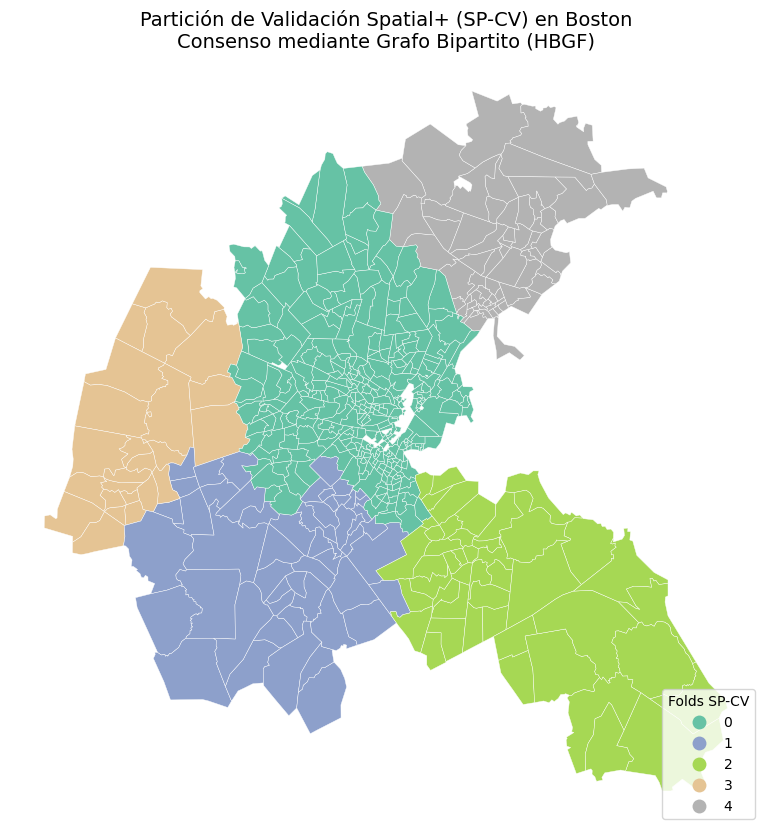

In [16]:
# ------------------------------------------------------------
# 10. VISUALIZACIÓN DE FOLDS
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_final.plot(
    column="fold",
    cmap="Set2",
    categorical=True,
    legend=True,
    legend_kwds={"title": "Folds SP-CV", "loc": "lower right"},
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

plt.title(
    "Partición de Validación Spatial+ (SP-CV) en Boston\n"
    "Consenso mediante Grafo Bipartito (HBGF)",
    fontsize=14
)

plt.axis("off")
plt.show()

In [17]:
# ------------------------------------------------------------
# 11. PREPARACIÓN FINAL PARA MODELO SAR
# ------------------------------------------------------------

todas_las_columnas = [
    target_col
] + covariables_list + [
    "fold",
    "block_id",
    "geometry"
]

gdf_limpio = gdf_final[todas_las_columnas].replace([np.inf, -np.inf], np.nan)

filas_antes = len(gdf_limpio)
gdf_limpio = gdf_limpio.dropna(subset=[target_col] + covariables_list + ["fold"])
filas_despues = len(gdf_limpio)

if filas_antes != filas_despues:
    print(f"Advertencia: se eliminaron {filas_antes - filas_despues} áreas de Boston por contener valores inválidos.")

gdf_limpio = gdf_limpio.reset_index(drop=True)

y = gdf_limpio[target_col].values.reshape(-1, 1)
X = gdf_limpio[covariables_list].values
folds = gdf_limpio["fold"].values

In [18]:
# ------------------------------------------------------------
# MATRIZ DE PESOS ESPACIALES (W)
# ------------------------------------------------------------

from libpysal.weights import Queen
from libpysal import weights

# Construcción de matriz Queen
W_global = Queen.from_dataframe(gdf_limpio, use_index=False)

# Estandarización por filas
W_global.transform = "R"

print("Matriz de pesos espaciales creada correctamente.")

# Información básica
print(f"Número de observaciones: {W_global.n}")

print(
    f"Número medio de vecinos: "
    f"{np.mean(list(W_global.cardinalities.values())):.2f}"
)

print(
    f"Número mínimo de vecinos: "
    f"{np.min(list(W_global.cardinalities.values()))}"
)

print(
    f"Número máximo de vecinos: "
    f"{np.max(list(W_global.cardinalities.values()))}"
)

Matriz de pesos espaciales creada correctamente.
Número de observaciones: 506
Número medio de vecinos: 5.75
Número mínimo de vecinos: 1
Número máximo de vecinos: 15


In [19]:
# ------------------------------------------------------------
# 12. MATRIZ DE PESOS ESPACIALES GLOBAL (W)
# ------------------------------------------------------------
from libpysal.weights import Queen
W_global = Queen.from_dataframe(gdf_limpio, use_index=False)
W_global.transform = "R"

print("Matriz de pesos espaciales global construida correctamente.")
print(f"Número de observaciones: {W_global.n}")
print(f"Número medio de vecinos: {np.mean(list(W_global.cardinalities.values())):.2f}")
print(f"Número mínimo de vecinos: {np.min(list(W_global.cardinalities.values()))}")
print(f"Número máximo de vecinos: {np.max(list(W_global.cardinalities.values()))}")

Matriz de pesos espaciales global construida correctamente.
Número de observaciones: 506
Número medio de vecinos: 5.75
Número mínimo de vecinos: 1
Número máximo de vecinos: 15


In [20]:
# ------------------------------------------------------------
# CONVERSIÓN DE W A MATRIZ
# ------------------------------------------------------------

W_matrix = W_global.full()[0]

W_df = pd.DataFrame(W_matrix)

print(W_df.shape)

W_df.head(10)

(506, 506)


,0,1,2,3,4,5,6,7,8,9,...,496,497,498,499,500,501,502,503,504,505
0,0.000000,0.125000,0.125000,0.000000,0.000000,0.125000,0.000000,0.125000,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.125000,0.125000,0.000000,0.125000,0.125000,0.000000,0.000000,0.000000,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.250000,0.250000,0.000000,0.250000,0.250000,0.000000,0.000000,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.111111,0.111111,0.000000,0.111111,0.111111,0.000000,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.166667,0.166667,0.000000,0.166667,0.166667,0.000000,0.166667,0.166667,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.000000,0.000000,0.000000,0.166667,0.166667,0.000000,0.166667,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.090909,0.000000,0.000000,0.000000,0.000000,0.090909,0.090909,0.000000,0.090909,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,0.000000,0.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
# ------------------------------------------------------------
# 13. VALIDACIÓN CRUZADA SPATIAL+ CON MODELO SAR
# ------------------------------------------------------------
from spreg import ML_Lag
sar_errors = []
rho_values = []

print("--- Iniciando Validación Cruzada SP-CV para Modelo SAR en Boston ---")

for fold_idx in range(5):
    train_mask = folds != fold_idx
    val_mask = folds == fold_idx
    
    gdf_train = gdf_limpio[train_mask]
    
    y_train = y[train_mask]
    X_train = X[train_mask]
    y_val = y[val_mask]
    X_val = X[val_mask]
    
    w_train = Queen.from_dataframe(gdf_train, use_index=False)
    w_train.transform = "R"
    
    model_sar = ML_Lag(
        y_train,
        X_train,
        w=w_train,
        name_y=target_col,
        name_x=covariables_list
    )
    
    rho_values.append(model_sar.rho)
    
    beta_coefficients = model_sar.betas[:-1]
    predictions = np.dot(X_val, beta_coefficients[1:]) + beta_coefficients[0]
    
    fold_rmse = np.sqrt(np.mean((y_val - predictions) ** 2))
    sar_errors.append(fold_rmse)
    
    print(
        f"Fold {fold_idx} aislado -> RMSE: {fold_rmse:.4f} | "
        f"Rho estimado (ρ): {model_sar.rho:.4f}"
    )

print("\n--- Resumen Final del Modelo SAR con SP-CV en Boston ---")
print(f"RMSE Promedio Final: {np.mean(sar_errors):.4f}")
print(f"Estabilidad de Rho Promedio: {np.mean(rho_values):.4f}")

--- Iniciando Validación Cruzada SP-CV para Modelo SAR en Boston ---


C:\Users\charl\anaconda3\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


ML_Lag
Fold 0 aislado -> RMSE: 0.8433 | Rho estimado (ρ): 0.2733
ML_Lag
Fold 1 aislado -> RMSE: 1.7572 | Rho estimado (ρ): 0.5366
ML_Lag
Fold 2 aislado -> RMSE: 1.6235 | Rho estimado (ρ): 0.5354
ML_Lag
Fold 3 aislado -> RMSE: 1.8461 | Rho estimado (ρ): 0.5378
ML_Lag
Fold 4 aislado -> RMSE: 1.7310 | Rho estimado (ρ): 0.5501

--- Resumen Final del Modelo SAR con SP-CV en Boston ---
RMSE Promedio Final: 1.5602
Estabilidad de Rho Promedio: 0.4866


In [59]:
# ------------------------------------------------------------
# 13. VALIDACIÓN CRUZADA SPATIAL+ CON MODELO SDEM
# ------------------------------------------------------------

from spreg import ML_Error

sdem_errors = []
lambda_values = []

print("--- Iniciando Validación Cruzada SP-CV para Modelo SDEM en Boston ---")

for fold_idx in range(5):
    train_mask = folds != fold_idx
    val_mask = folds == fold_idx
    
    gdf_train = gdf_limpio[train_mask]
    
    y_train = y[train_mask]
    X_train = X[train_mask]
    y_val = y[val_mask]
    X_val = X[val_mask]
    
    # Matriz W del conjunto de entrenamiento
    w_train = Queen.from_dataframe(gdf_train, use_index=False)
    w_train.transform = "R"
    
    # Modelo SDEM: Spatial Error + rezagos espaciales de X
    model_sdem = ML_Error(
        y_train,
        X_train,
        w=w_train,
        slx_lags=1,
        name_y=target_col,
        name_x=covariables_list
    )
    
    # Lambda espacial del error
    lambda_values.append(model_sdem.lam)
    
    # Predicción aproximada sobre validación
    beta_coefficients = model_sdem.betas.flatten()
    
    n_x = X_val.shape[1]
    
    intercept = beta_coefficients[0]
    betas_x = beta_coefficients[1:1+n_x]
    
    predictions = intercept + np.dot(X_val, betas_x)
    
    fold_rmse = np.sqrt(np.mean((y_val - predictions.reshape(-1, 1)) ** 2))
    sdem_errors.append(fold_rmse)
    
    print(
        f"Fold {fold_idx} aislado -> RMSE: {fold_rmse:.4f} | "
        f"Lambda estimado (λ): {model_sdem.lam:.4f}"
    )

print("\n--- Resumen Final del Modelo SDEM con SP-CV en Boston ---")
print(f"RMSE Promedio Final: {np.mean(sdem_errors):.4f}")
print(f"Estabilidad de Lambda Promedio: {np.mean(lambda_values):.4f}")

--- Iniciando Validación Cruzada SP-CV para Modelo SDEM en Boston ---


C:\Users\charl\anaconda3\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
Fold 0 aislado -> RMSE: 0.7504 | Lambda estimado (λ): 0.4900
ML_Error
Fold 1 aislado -> RMSE: 0.7307 | Lambda estimado (λ): 0.6837


C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
Fold 2 aislado -> RMSE: 0.9252 | Lambda estimado (λ): 0.6877
ML_Error
Fold 3 aislado -> RMSE: 0.7319 | Lambda estimado (λ): 0.6895


C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
Fold 4 aislado -> RMSE: 0.7375 | Lambda estimado (λ): 0.6891

--- Resumen Final del Modelo SDEM con SP-CV en Boston ---
RMSE Promedio Final: 0.7752
Estabilidad de Lambda Promedio: 0.6480


In [60]:
# ------------------------------------------------------------
# 13. VALIDACIÓN CRUZADA SPATIAL+ CON MODELO SEM
# ------------------------------------------------------------

from spreg import ML_Error

sem_errors = []
lambda_values = []

print("--- Iniciando Validación Cruzada SP-CV para Modelo SEM en Boston ---")

for fold_idx in range(5):
    train_mask = folds != fold_idx
    val_mask = folds == fold_idx
    
    gdf_train = gdf_limpio[train_mask]
    
    y_train = y[train_mask]
    X_train = X[train_mask]
    y_val = y[val_mask]
    X_val = X[val_mask]
    
    # Matriz W del conjunto de entrenamiento
    w_train = Queen.from_dataframe(gdf_train, use_index=False)
    w_train.transform = "R"
    
    # Modelo SEM: Spatial Error Model
    model_sem = ML_Error(
        y_train,
        X_train,
        w=w_train,
        name_y=target_col,
        name_x=covariables_list
    )
    
    lambda_values.append(model_sem.lam)
    
    beta_coefficients = model_sem.betas.flatten()
    
    intercept = beta_coefficients[0]
    betas_x = beta_coefficients[1:1 + X_val.shape[1]]
    
    predictions = intercept + np.dot(X_val, betas_x)
    
    fold_rmse = np.sqrt(np.mean((y_val - predictions.reshape(-1, 1)) ** 2))
    sem_errors.append(fold_rmse)
    
    print(
        f"Fold {fold_idx} aislado -> RMSE: {fold_rmse:.4f} | "
        f"Lambda estimado (λ): {model_sem.lam:.4f}"
    )

print("\n--- Resumen Final del Modelo SEM con SP-CV en Boston ---")
print(f"RMSE Promedio Final: {np.mean(sem_errors):.4f}")
print(f"Estabilidad de Lambda Promedio: {np.mean(lambda_values):.4f}")

--- Iniciando Validación Cruzada SP-CV para Modelo SEM en Boston ---
ML_Error
Fold 0 aislado -> RMSE: 0.3014 | Lambda estimado (λ): 0.6139


C:\Users\charl\anaconda3\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
Fold 1 aislado -> RMSE: 0.1609 | Lambda estimado (λ): 0.7605


C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
Fold 2 aislado -> RMSE: 0.1149 | Lambda estimado (λ): 0.7636
ML_Error
Fold 3 aislado -> RMSE: 0.1727 | Lambda estimado (λ): 0.7616
ML_Error
Fold 4 aislado -> RMSE: 0.1202 | Lambda estimado (λ): 0.7619

--- Resumen Final del Modelo SEM con SP-CV en Boston ---
RMSE Promedio Final: 0.1740
Estabilidad de Lambda Promedio: 0.7323


C:\Users\charl\anaconda3\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
